In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings 

warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


In [4]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [5]:
df.isna().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='HeartDisease'>

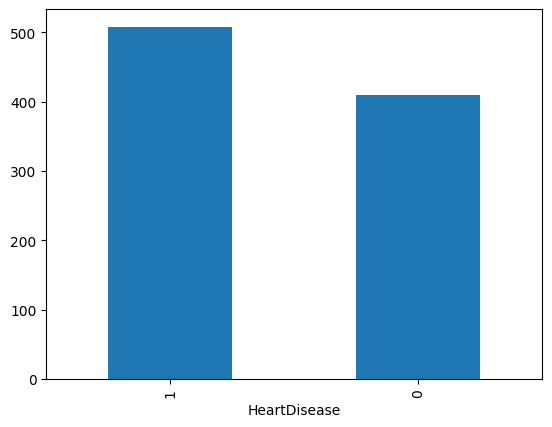

In [7]:
df['HeartDisease'].value_counts().plot(kind="bar")

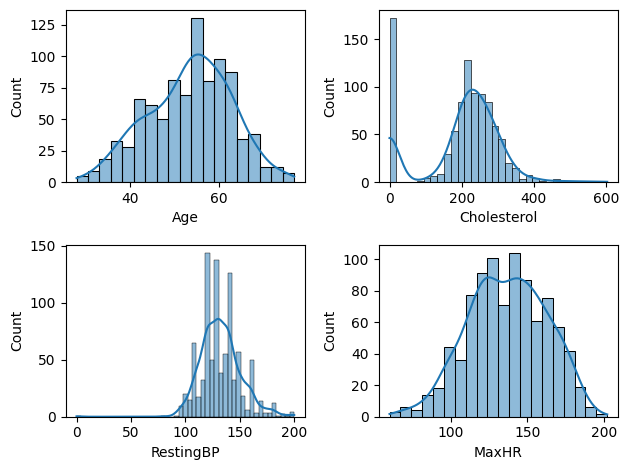

In [8]:
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(df[var],kde=True)

plotting('Age',1)
plotting('Cholesterol',2)
plotting('RestingBP',3)
plotting('MaxHR',4)

plt.tight_layout()

In [10]:
# we will find mean of all cholestrol value and replace with 0
ch_mean = df.loc[df['Cholesterol'] !=0,'Cholesterol' ].mean()
ch_mean

np.float64(244.6353887399464)

In [11]:
df['Cholesterol'] = df['Cholesterol'].replace(0, ch_mean).round(2)

In [12]:
df['Cholesterol'].value_counts()

Cholesterol
244.64    172
254.00     11
223.00     10
220.00     10
211.00      9
         ... 
353.00      1
278.00      1
157.00      1
176.00      1
131.00      1
Name: count, Length: 222, dtype: int64

In [13]:
# same with RestingBP

bp_mean = df.loc[df['RestingBP'] !=0,'RestingBP' ].mean()
bp_mean

np.float64(132.54089422028352)

In [14]:
df['RestingBP']=df['RestingBP'].replace(0,bp_mean).round(2)
df['RestingBP'].value_counts()

RestingBP
120.0    132
130.0    118
140.0    107
110.0     58
150.0     55
        ... 
174.0      1
117.0      1
192.0      1
129.0      1
164.0      1
Name: count, Length: 67, dtype: int64

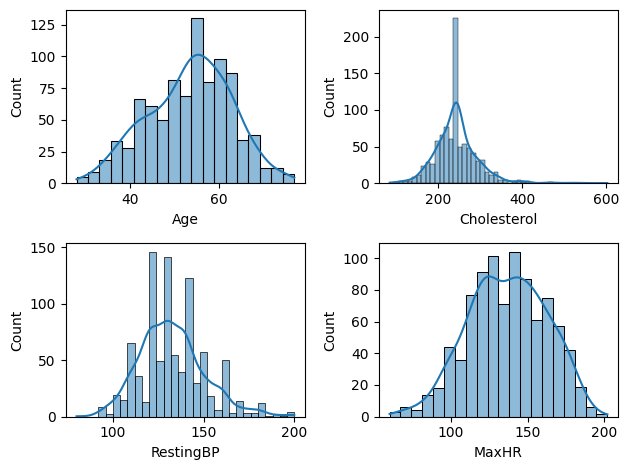

In [15]:
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(df[var],kde=True)

plotting('Age',1)
plotting('Cholesterol',2)
plotting('RestingBP',3)
plotting('MaxHR',4)

plt.tight_layout()

<Axes: xlabel='Sex', ylabel='count'>

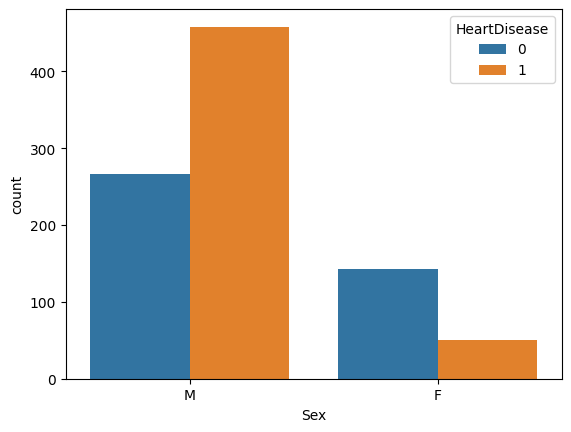

In [16]:
sns.countplot(x=df['Sex'] , hue=df['HeartDisease'])

<Axes: xlabel='ChestPainType', ylabel='count'>

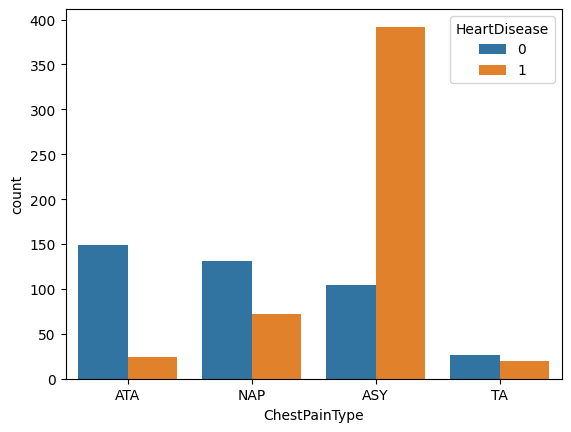

In [17]:
sns.countplot(x=df['ChestPainType'],  hue=df['HeartDisease'])

<Axes: xlabel='RestingECG', ylabel='count'>

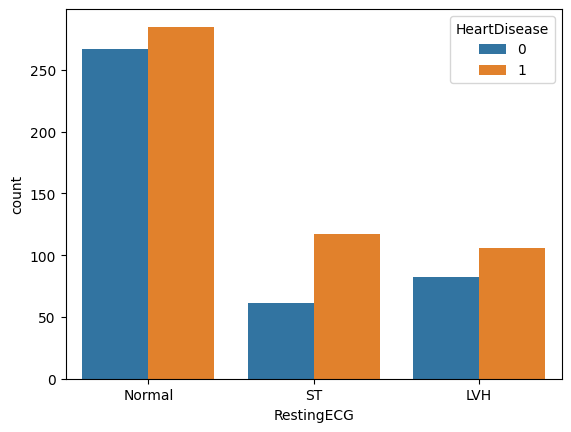

In [18]:
sns.countplot(x=df['RestingECG'],  hue=df['HeartDisease'])

<Axes: xlabel='ExerciseAngina', ylabel='count'>

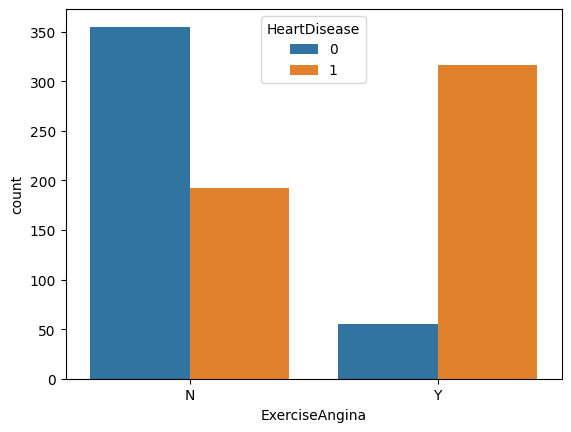

In [19]:
sns.countplot(x=df['ExerciseAngina'],  hue=df['HeartDisease'])

<Axes: xlabel='ST_Slope', ylabel='count'>

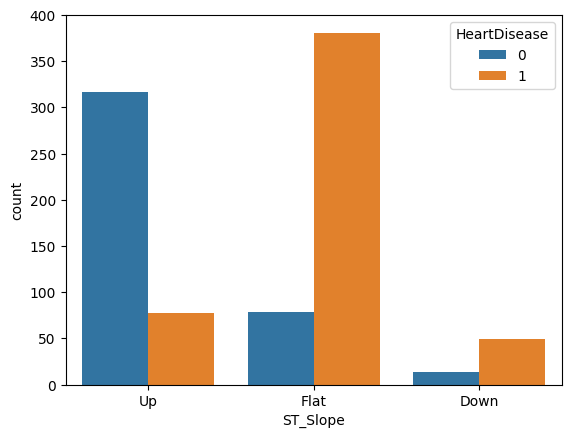

In [20]:
sns.countplot(x=df['ST_Slope'],  hue=df['HeartDisease'])

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

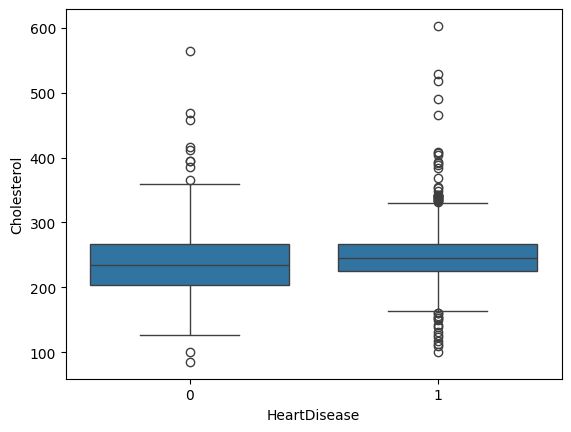

In [21]:
sns.boxplot(x=df['HeartDisease'],y=df['Cholesterol'])

<Axes: xlabel='HeartDisease', ylabel='Age'>

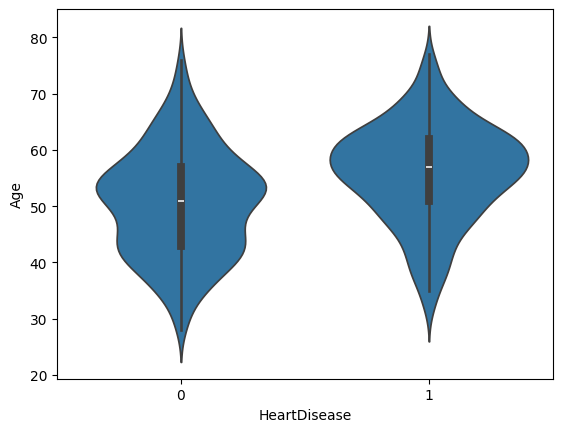

In [22]:
sns.violinplot(x=df['HeartDisease'],y=df['Age'])

<Axes: >

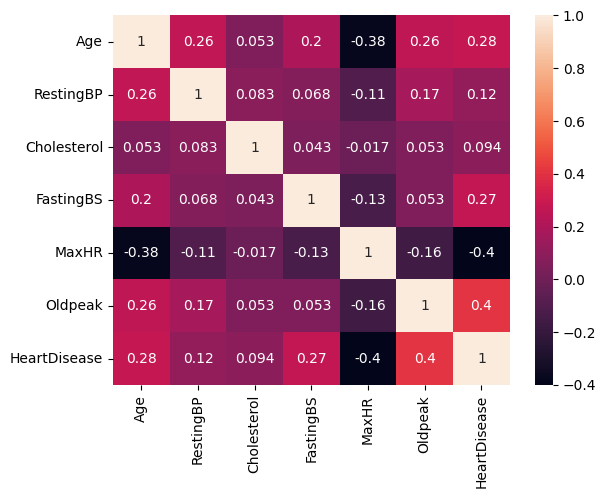

In [23]:
sns.heatmap(df.corr(numeric_only=True) , annot=True)

# DATA CLEANING AND PREPROCESSING

In [24]:
df_encode= pd.get_dummies(df ,drop_first=True )

In [25]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138.0,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150.0,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110.0,264.0,0,132,1.2,1,True,False,False,True,True,False,False,True,False
914,68,144.0,193.0,1,141,3.4,1,True,False,False,False,True,False,False,True,False
915,57,130.0,131.0,0,115,1.2,1,True,False,False,False,True,False,True,True,False
916,57,130.0,236.0,0,174,0.0,1,False,True,False,False,False,False,False,True,False


In [30]:
df_encode= df_encode.astype(int)
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,1,0,0,1,1,0,0,1,0
914,68,144,193,1,141,3,1,1,0,0,0,1,0,0,1,0
915,57,130,131,0,115,1,1,1,0,0,0,1,0,1,1,0
916,57,130,236,0,174,0,1,0,1,0,0,0,0,0,1,0


In [44]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score , f1_score,confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

In [45]:
X= df_encode.drop('HeartDisease' , axis=1)
y=df_encode['HeartDisease']

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y,stratify=y, test_size=0.20, random_state=42)

In [60]:
scaler = StandardScaler()
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled= scaler.fit_transform(X_test)

In [83]:
models = {
    "Logistic Regression" : LogisticRegression(), 
    "KNN" : KNeighborsClassifier(), 
    "Naive Bayes" : GaussianNB(), 
    "SVM (RBF Kernel)": SVC(probability=True),
    "Decision Tree": DecisionTreeClassifier()    
}

In [84]:
result = []


In [85]:
for name , model in models.items():
    model.fit(X_train_scaled , y_train)
    y_pred= model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test , y_pred)
    f1 = f1_score(y_test , y_pred)

    result.append({
        'model': name, 
        'Accuracy' : round(accuracy,4),
        'f1_score' : round(f1,4)
    })

In [86]:
result

[{'model': 'Logistic Regression', 'Accuracy': 0.8967, 'f1_score': 0.91},
 {'model': 'KNN', 'Accuracy': 0.8804, 'f1_score': 0.8942},
 {'model': 'Naive Bayes', 'Accuracy': 0.8804, 'f1_score': 0.89},
 {'model': 'SVM (RBF Kernel)', 'Accuracy': 0.8641, 'f1_score': 0.8815},
 {'model': 'Decision Tree', 'Accuracy': 0.7337, 'f1_score': 0.7538}]

In [87]:
result

[{'model': 'Logistic Regression', 'Accuracy': 0.8967, 'f1_score': 0.91},
 {'model': 'KNN', 'Accuracy': 0.8804, 'f1_score': 0.8942},
 {'model': 'Naive Bayes', 'Accuracy': 0.8804, 'f1_score': 0.89},
 {'model': 'SVM (RBF Kernel)', 'Accuracy': 0.8641, 'f1_score': 0.8815},
 {'model': 'Decision Tree', 'Accuracy': 0.7337, 'f1_score': 0.7538}]

 now we find that KNN model is giving best accuracy 
we will save this model in pikle file so that we can uuse it with frontend

In [88]:
import joblib
joblib.dump(models['KNN'],'KNN_heart.pkl')
joblib.dump(scaler,'scaler.pkl')
joblib.dump(X.columns.tolist(),'columns.pkl')

['columns.pkl']